In [ ]:
!pip install opencv-python



In [ ]:
from google.colab import files
import cv2
import numpy as np
from IPython.display import display, Image
from io import BytesIO
from PIL import Image as PILImage

In [ ]:
# Utility function to display images in Colab
def display_image(image):
    _, buffer = cv2.imencode('.png', image)
    img = PILImage.open(BytesIO(buffer))
    display(img)

# Function to read uploaded image file
def read_image(uploaded_file):
    image_data = np.frombuffer(uploaded_file.read(), np.uint8)
    img = cv2.imdecode(image_data, cv2.IMREAD_COLOR)
    return img


Saving Periodic-noise-removal-by-Frequency-Domain-Median-Filter.jpg to Periodic-noise-removal-by-Frequency-Domain-Median-Filter.jpg


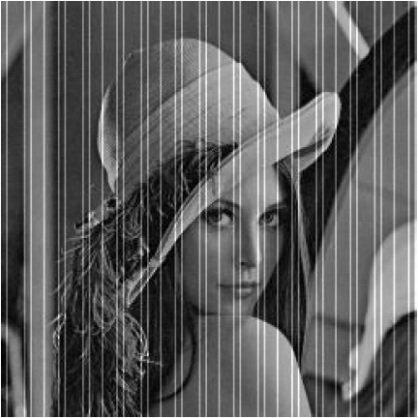

In [ ]:
# Ask the user to upload an image file
uploaded = files.upload()

# Extracting image from the uploaded files
for filename in uploaded.keys():
    # uploaded[filename] is a bytes object, wrap it in BytesIO to create
    # a file-like object
    img = read_image(BytesIO(uploaded[filename]))
    display_image(img)

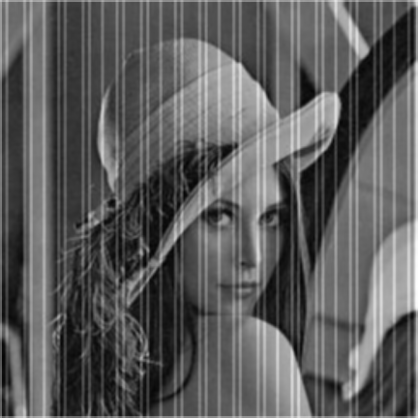

In [ ]:
def apply_convolution(image, kernel_type="average"):
    if kernel_type == "average":
        kernel = np.ones((3, 3), np.float32) / 9
    elif kernel_type == "sharpen":
        kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    elif kernel_type == "edge":
        kernel = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])

    output_img = cv2.filter2D(image, -1, kernel)
    return output_img

# Test convolution
if img is not None:
    result = apply_convolution(img, "average")
    display_image(result)


Zero Padding

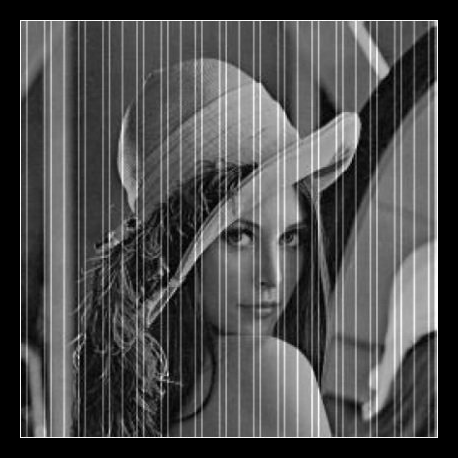

In [ ]:
def apply_zero_padding(image, padding_size=10):
    padded_img = cv2.copyMakeBorder(image, padding_size, padding_size, padding_size, padding_size, cv2.BORDER_CONSTANT, value=[0, 0, 0])
    return padded_img

# Test zero padding
if img is not None:
    result = apply_zero_padding(img, 20)
    display_image(result)


Low,High, Band Pass Filter

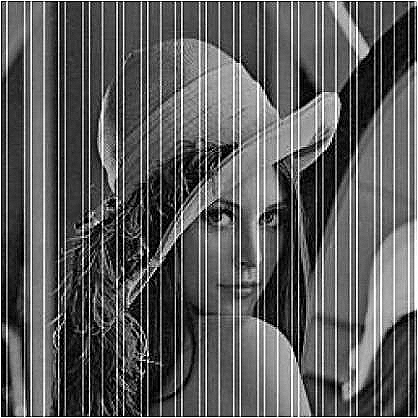

In [ ]:
def apply_filter(image, filter_type="low"):
    if filter_type == "low":
        filtered_img = cv2.GaussianBlur(image, (5, 5), 0)
    elif filter_type == "high":
        kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
        filtered_img = cv2.filter2D(image, -1, kernel)
    elif filter_type == "band":
        low_pass = cv2.GaussianBlur(image, (9, 9), 0)
        high_pass = image - low_pass
        filtered_img = low_pass + high_pass

    return filtered_img

# Test filter
if img is not None:
    result = apply_filter(img, "high")
    display_image(result)


Fourier Transform

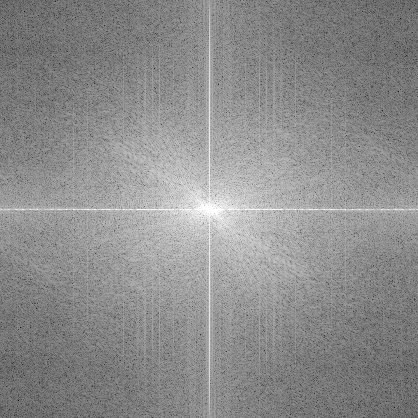

In [ ]:
def apply_fourier_transform(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift))
    return magnitude_spectrum

# Test Fourier Transform
if img is not None:
    result = apply_fourier_transform(img)
    display_image(result)


Reduce Periodic Noise

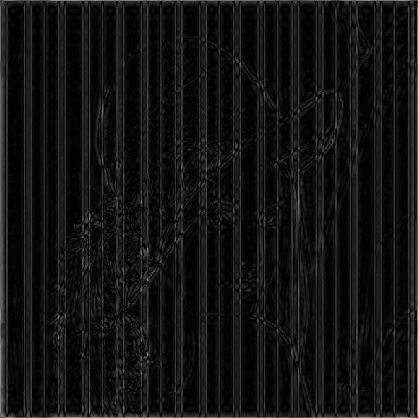

In [ ]:
def reduce_periodic_noise(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)

    # Create a mask to remove periodic noise
    rows, cols = gray.shape
    crow, ccol = rows // 2, cols // 2
    mask = np.ones((rows, cols), np.uint8)
    r = 30  # Radius of the mask
    mask[crow-r:crow+r, ccol-r:ccol+r] = 0

    fshift = fshift * mask
    f_ishift = np.fft.ifftshift(fshift)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    return img_back

# Test reducing periodic noise
if img is not None:
    result = reduce_periodic_noise(img)
    display_image(result)
